In [1]:
# ── Librerías ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import janitor
import sqlalchemy as sa
import os
from pathlib import Path
from dotenv import load_dotenv

%matplotlib inline

# ── Opciones de visualización ─────────────────────────────────────────
# Desactivar notación científica
pd.set_option('display.float_format', '{:.3f}'.format)
np.set_printoptions(suppress=True)

# Ver todas las columnas al imprimir un DataFrame
pd.set_option('display.max_columns', None)

# ── Rutas del proyecto ────────────────────────────────────────────────
# Se resuelven desde la ubicación del notebook, así funcionan
# igual en cualquier máquina
RAIZ = Path.cwd().parent

ORIGINALES   = RAIZ / '02_datos' / '01_Originales'
VALIDACION   = RAIZ / '02_datos' / '02_Validacion'
ENTRENAMIENTO = RAIZ / '02_datos' / '03_Entrenamiento'
CACHES       = RAIZ / '02_datos' / '04_Caches'
MODELOS      = RAIZ / '05_modelos'
RESULTADOS   = RAIZ / '06_resultados'

# ── Variables de entorno ──────────────────────────────────────────────
load_dotenv(RAIZ / '.env')

print('✅ Entorno listo')
print(f'   Raíz del proyecto: {RAIZ}')

✅ Entorno listo
   Raíz del proyecto: c:\Users\Admin\Desktop\Desktop\CarpetaFisica\Data Detective\Ciencia_Datos_2\Caso_Agentes


# 🧪 07 — Modelización

**Agente**: A_07_Modelizador
**Objetivo**: identificar el algoritmo ganador y su combinación de hiperparámetros mediante validación cruzada, y dejar la configuración persistida para que un agente posterior entrene el modelo definitivo.

Problema: **clasificación binaria** — target `contrata_fondos` (0/1).

In [2]:
# ── Carga del dataframe de entrenamiento actual ─────────────────────
# Datos ya transformados y con la selección de variables aplicada
RUTA_DF = ENTRENAMIENTO / '05_train_tablon_preseleccion.pkl'

df = pd.read_pickle(RUTA_DF)

print('✅ Dataframe cargado')
print(f'   Ruta      : {RUTA_DF}')
print(f'   Shape     : {df.shape[0]} filas x {df.shape[1]} columnas')
print()

# ── Resumen de estructura ───────────────────────────────────────────
df.info()

# ── Distribución de la target ────────────────────────────────────────
print('\n── Distribución de la variable target: contrata_fondos ──')
conteo = df['contrata_fondos'].value_counts().sort_index()
for valor in conteo.index:
    n = conteo.loc[valor]
    pct = 100.0 * n / len(df)
    print(f'   contrata_fondos = {valor}: {n:>6} filas  ({pct:.2f}%)')

tasa_positivos = 100.0 * df['contrata_fondos'].sum() / len(df)
print(f'\n📊 Tasa de positivos (clase 1): {tasa_positivos:.2f}%')
print(f'   Total filas: {len(df)}')


✅ Dataframe cargado
   Ruta      : c:\Users\Admin\Desktop\Desktop\CarpetaFisica\Data Detective\Ciencia_Datos_2\Caso_Agentes\02_datos\03_Entrenamiento\05_train_tablon_preseleccion.pkl
   Shape     : 28015 filas x 13 columnas

<class 'pandas.DataFrame'>
RangeIndex: 28015 entries, 0 to 28014
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   trabajo_student                         28015 non-null  int8   
 1   impago_unknown                          28015 non-null  int8   
 2   prestamo_hipotecario_yes                28015 non-null  int8   
 3   canal_de_contacto_telephone             28015 non-null  int8   
 4   mes_sin                                 28015 non-null  float64
 5   mes_cos                                 28015 non-null  float64
 6   resultado_campana_anterior_nonexistent  28015 non-null  int8   
 7   resultado_campana_anterior_success      28015 non-n

## ⚙️ FASE 2 — Ejecución

**Configuración del experimento (aprobada):**

- Target: `contrata_fondos` · clasificación binaria · **métrica: AUC**
- Muestra: dataset completo (28.015 × 12)
- Algoritmos: LogisticRegression (L2), RandomForest, HistGradientBoosting
  *(XGBoost descartado por el momento: no está instalado y buscamos rapidez)*
- CV: **StratifiedKFold(3)** · RandomizedSearchCV · **5 iteraciones** por algoritmo

### Tarea 1: Preparación de la muestra y CV

In [3]:
# ── FASE 2 · Tarea 1: Preparación de X/y y validación cruzada ────
# Las variables ya vienen en escala comparable (one-hot 0/1,
# mes_sin/mes_cos en [-1, 1] y columnas _ss tipificadas), por lo que
# NO se requiere escalado adicional.

TARGET = 'contrata_fondos'
RANDOM_STATE = 42

# ── Separación X / y ────────────────────────────────────────────────
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

print('✅ X / y preparados')
print(f'   X: {X.shape[0]} filas x {X.shape[1]} columnas')
print(f'   y: {y.shape[0]} filas | positivos: {y.sum()} ({100.0*y.mean():.2f}%)')
print(f'\n   Variables predictoras ({X.shape[1]}):')
for col in X.columns:
    print(f'     - {col}')

# ── Configuración de la validación cruzada ──────────────────────────
from sklearn.model_selection import StratifiedKFold

N_FOLDS = 3

cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
print(f'\n✅ CV configurada: StratifiedKFold(n_splits={N_FOLDS}, shuffle=True)')

# ── Verificación de la distribución de clases por fold ──────────────
print('\n── Distribución de positivos por fold ──')
for fold, (idx_tr, idx_va) in enumerate(cv.split(X, y), start=1):
    tasa_tr = 100.0 * y.iloc[idx_tr].mean()
    tasa_va = 100.0 * y.iloc[idx_va].mean()
    n_pos_va = int(y.iloc[idx_va].sum())
    print(f'   Fold {fold}: train {len(idx_tr):>6} filas ({tasa_tr:.2f}%+) '
          f'| val {len(idx_va):>5} filas ({tasa_va:.2f}%+, {n_pos_va} positivos)')


✅ X / y preparados
   X: 28015 filas x 12 columnas
   y: 28015 filas | positivos: 3234 (11.54%)

   Variables predictoras (12):
     - trabajo_student
     - impago_unknown
     - prestamo_hipotecario_yes
     - canal_de_contacto_telephone
     - mes_sin
     - mes_cos
     - resultado_campana_anterior_nonexistent
     - resultado_campana_anterior_success
     - edad_ss
     - num_contactos_esta_campana_log_ss
     - variacion_tasa_empleo_ss
     - euribor3m_ss

✅ CV configurada: StratifiedKFold(n_splits=3, shuffle=True)

── Distribución de positivos por fold ──
   Fold 1: train  18676 filas (11.54%+) | val  9339 filas (11.54%+, 1078 positivos)
   Fold 2: train  18677 filas (11.54%+) | val  9338 filas (11.54%+, 1078 positivos)
   Fold 3: train  18677 filas (11.54%+) | val  9338 filas (11.54%+, 1078 positivos)


### Tarea 2: Espacios de hiperparámetros por algoritmo

In [ ]:
# ── FASE 2 · Tarea 2: Espacios de hiperparámetros por algoritmo ────
# Cada algoritmo se define con:
#   - 'clase' : clase del estimador de sklearn
#   - 'fijos' : hiperparámetros fijos del constructor
#   - 'grid'  : valores discretos que muestreará RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

CONFIG_MODELOS = {}

# ── 1) LogisticRegression (baseline, regularización L2 / Ridge) ────
CONFIG_MODELOS['LogisticRegression'] = {
    'clase': LogisticRegression,
    # Nota: la regularización L2 (Ridge) ya es el valor por defecto;
    # se omite 'penalty' explícito por su deprecación en sklearn >= 1.8
    'fijos': {
        'solver': 'lbfgs',
        'max_iter': 2000,
        'random_state': RANDOM_STATE,
    },
    'grid': {
        'C': [0.001, 0.01, 0.1, 1.0, 10.0],
    },
}

# ── 2) RandomForestClassifier ────────────────────────────────────────
CONFIG_MODELOS['RandomForest'] = {
    'clase': RandomForestClassifier,
    'fijos': {
        'max_features': 'sqrt',
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
    },
    'grid': {
        'n_estimators': [200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'class_weight': [None, 'balanced'],
    },
}

# ── 3) HistGradientBoostingClassifier ────────────────────────────────
CONFIG_MODELOS['HistGradientBoosting'] = {
    'clase': HistGradientBoostingClassifier,
    'fijos': {
        'random_state': RANDOM_STATE,
    },
    'grid': {
        'learning_rate': [0.05, 0.1, 0.2],
        'max_iter': [200, 300],
        'max_leaf_nodes': [15, 31],
        'min_samples_leaf': [20, 100],
        'l2_regularization': [0.0, 0.1, 1.0],
    },
}

# ── Resumen de la configuración ──────────────────────────────────────
print('✅ Espacios de hiperparámetros definidos\n')
for nombre, cfg in CONFIG_MODELOS.items():
    print(f'── {nombre} ──')
    print(f'   Fijos : {cfg["fijos"]}')
    print(f'   Grid  :')
    for hp, valores in cfg['grid'].items():
        print(f'     - {hp}: {valores}')
    print()


✅ Espacios de hiperparámetros definidos

── LogisticRegression ──
   Fijos : {'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 2000, 'random_state': 42}
   Grid  :
     - C: [0.001, 0.01, 0.1, 1.0, 10.0]

── RandomForest ──
   Fijos : {'max_features': 'sqrt', 'random_state': 42, 'n_jobs': -1}
   Grid  :
     - n_estimators: [200, 300]
     - max_depth: [None, 10, 20, 30]
     - min_samples_split: [2, 5, 10]
     - min_samples_leaf: [1, 2, 4]
     - class_weight: [None, 'balanced']

── HistGradientBoosting ──
   Fijos : {'random_state': 42}
   Grid  :
     - learning_rate: [0.05, 0.1, 0.2]
     - max_iter: [200, 300]
     - max_leaf_nodes: [15, 31]
     - min_samples_leaf: [20, 100]
     - l2_regularization: [0.0, 0.1, 1.0]



### Tarea 3: Búsqueda de modelos con RandomizedSearchCV

In [5]:
# ── FASE 2 · Tarea 3: Búsqueda de modelos (RandomizedSearchCV) ────
import time
from sklearn.model_selection import RandomizedSearchCV

N_ITER = 5          # iteraciones de random search por algoritmo
SCORING = 'roc_auc' # métrica principal de optimización

resultados = {}

for nombre, cfg in CONFIG_MODELOS.items():
    print(f'▶ Buscando hiperparámetros: {nombre} ...')

    # Se instancia el estimador con los parámetros fijos
    estimador = cfg['clase'](**cfg['fijos'])

    busqueda = RandomizedSearchCV(
        estimator=estimador,
        param_distributions=cfg['grid'],
        n_iter=N_ITER,
        cv=cv,
        scoring=SCORING,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        refit=True,
        return_train_score=False,
    )

    t0 = time.time()
    busqueda.fit(X, y)
    t_total = time.time() - t0

    # Métricas del mejor modelo
    media = busqueda.cv_results_['mean_test_score'][busqueda.best_index_]
    std = busqueda.cv_results_['std_test_score'][busqueda.best_index_]

    resultados[nombre] = {
        'best_params': busqueda.best_params_,
        'best_score': media,
        'best_std': std,
        'cv_results': busqueda.cv_results_,
        'tiempo_s': t_total,
        'mejor_estimador': busqueda.best_estimator_,
    }

    print(f'   ✔ AUC CV = {media:.4f} ± {std:.4f}  (tiempo: {t_total:.0f}s)')
    print(f'   Mejores parámetros: {busqueda.best_params_}')
    print()

print('🏁 Búsqueda finalizada')


▶ Buscando hiperparámetros: LogisticRegression ...


c:\Users\Admin\Desktop\Desktop\CarpetaFisica\Data Detective\Ciencia_Datos_2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


   ✔ AUC CV = 0.7733 ± 0.0039  (tiempo: 49s)
   Mejores parámetros: {'C': 0.1}

▶ Buscando hiperparámetros: RandomForest ...
   ✔ AUC CV = 0.8006 ± 0.0024  (tiempo: 60s)
   Mejores parámetros: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10, 'class_weight': None}

▶ Buscando hiperparámetros: HistGradientBoosting ...
   ✔ AUC CV = 0.8015 ± 0.0032  (tiempo: 9s)
   Mejores parámetros: {'min_samples_leaf': 20, 'max_leaf_nodes': 15, 'max_iter': 300, 'learning_rate': 0.05, 'l2_regularization': 0.1}

🏁 Búsqueda finalizada


### Tarea 4: Ranking comparativo de modelos

In [6]:
# ── FASE 2 · Tarea 4: Ranking comparativo de modelos ───────────────
filas_ranking = []
for nombre, r in resultados.items():
    filas_ranking.append({
        'algoritmo': nombre,
        'auc_cv': round(r['best_score'], 4),
        'auc_std': round(r['best_std'], 4),
        'tiempo_s': round(r['tiempo_s'], 1),
        'best_params': str(r['best_params']),
    })

df_ranking = pd.DataFrame(filas_ranking)
df_ranking = df_ranking.sort_values('auc_cv', ascending=False).reset_index(drop=True)
df_ranking.insert(0, 'posicion', range(1, len(df_ranking) + 1))

print('🏆 Ranking de modelos por AUC (validación cruzada · 3 folds)')
print(df_ranking.to_string(index=False))


🏆 Ranking de modelos por AUC (validación cruzada · 3 folds)
 posicion            algoritmo  auc_cv  auc_std  tiempo_s                                                                                                      best_params
        1 HistGradientBoosting   0.801    0.003     8.900 {'min_samples_leaf': 20, 'max_leaf_nodes': 15, 'max_iter': 300, 'learning_rate': 0.05, 'l2_regularization': 0.1}
        2         RandomForest   0.801    0.002    59.800      {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10, 'class_weight': None}
        3   LogisticRegression   0.773    0.004    49.200                                                                                                       {'C': 0.1}


### Tarea 5: Interpretabilidad del modelo ganador (RandomForest)

In [7]:
# ── FASE 2 · Tarea 5: Interpretabilidad del modelo ganador (RF) ────
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

# Modelo ganador según decisión del usuario
NOMBRE_GANADOR = 'RandomForest'

print(f'🏆 Modelo ganador: {NOMBRE_GANADOR}')
print(f'   AUC CV: {resultados[NOMBRE_GANADOR]["best_score"]:.4f} '
      f'± {resultados[NOMBRE_GANADOR]["best_std"]:.4f}')
print(f'   Hiperparámetros: {resultados[NOMBRE_GANADOR]["best_params"]}')

# ── Importancia interna (feature_importances_) ──────────────────────
imp_interna = resultados[NOMBRE_GANADOR]['mejor_estimador'].feature_importances_

df_imp_interna = pd.DataFrame({
    'variable': X.columns,
    'importancia_interna': imp_interna,
}).sort_values('importancia_interna', ascending=False).reset_index(drop=True)

print('\n── Importancia interna del modelo (feature_importances_) ──')
print(df_imp_interna.to_string(index=False))

# ── Permutation Importance (estimación limpia 75/25) ────────────────
# Se reentrena un RF con los parámetros ganadores sobre el 75% y se
# evalúa el impacto en AUC al permutar cada variable sobre el 25%.
X_tr, X_va, y_tr, y_va = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE,
)

fijos_rf = CONFIG_MODELOS[NOMBRE_GANADOR]['fijos']
hp_rf = resultados[NOMBRE_GANADOR]['best_params']

modelo_perm = RandomForestClassifier(**fijos_rf, **hp_rf)
modelo_perm.fit(X_tr, y_tr)

print(f'\n   Permutation Importance: modelo entrenado con {len(X_tr)} filas '
      f'y evaluado sobre {len(X_va)} filas (25%)')

perm = permutation_importance(
    modelo_perm, X_va, y_va,
    scoring='roc_auc',
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

df_perm = pd.DataFrame({
    'variable': X.columns,
    'importancia_perm': perm.importances_mean,
    'desv_perm': perm.importances_std,
}).sort_values('importancia_perm', ascending=False).reset_index(drop=True)

print('\n── Permutation Importance (impacto en AUC) ──')
print(df_perm.to_string(index=False))


🏆 Modelo ganador: RandomForest
   AUC CV: 0.8006 ± 0.0024
   Hiperparámetros: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10, 'class_weight': None}

── Importancia interna del modelo (feature_importances_) ──
                              variable  importancia_interna
                          euribor3m_ss                0.230
    resultado_campana_anterior_success                0.196
              variacion_tasa_empleo_ss                0.171
                               edad_ss                0.115
                               mes_sin                0.080
                               mes_cos                0.058
     num_contactos_esta_campana_log_ss                0.047
resultado_campana_anterior_nonexistent                0.035
           canal_de_contacto_telephone                0.029
              prestamo_hipotecario_yes                0.015
                        impago_unknown                0.013
                       trabajo_st

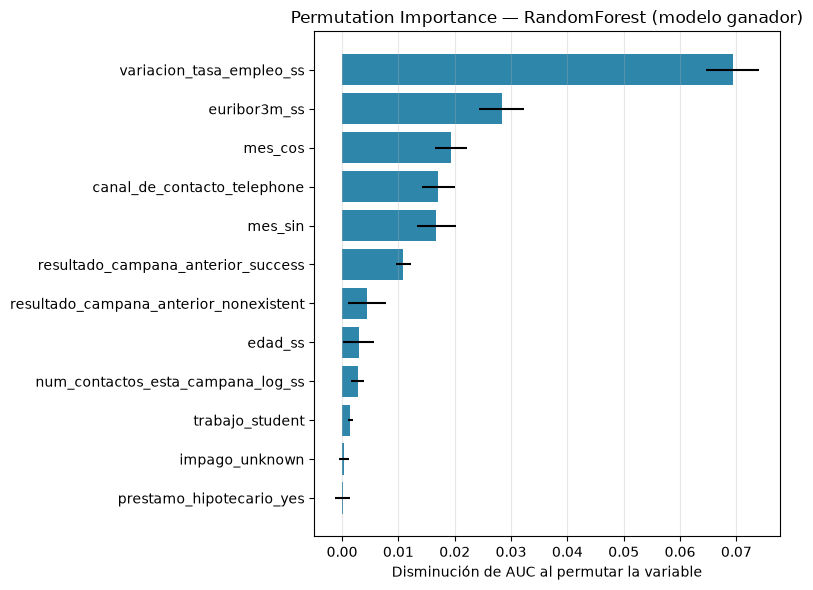

In [8]:
# ── Gráfico: Permutation Importance ─────────────────────────────────
df_perm_graf = df_perm.sort_values('importancia_perm', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(df_perm_graf['variable'], df_perm_graf['importancia_perm'],
        xerr=df_perm_graf['desv_perm'], color='#2E86AB')
ax.set_xlabel('Disminución de AUC al permutar la variable')
ax.set_title('Permutation Importance — RandomForest (modelo ganador)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


### Curvas de evaluación del modelo ganador (ROC y Gain/Lift)

Evaluación honesta sobre el **25% reservado**: el modelo se entrenó únicamente con el 75% de los datos.

🎯 AUC en hold-out (25% reservado): 0.8009


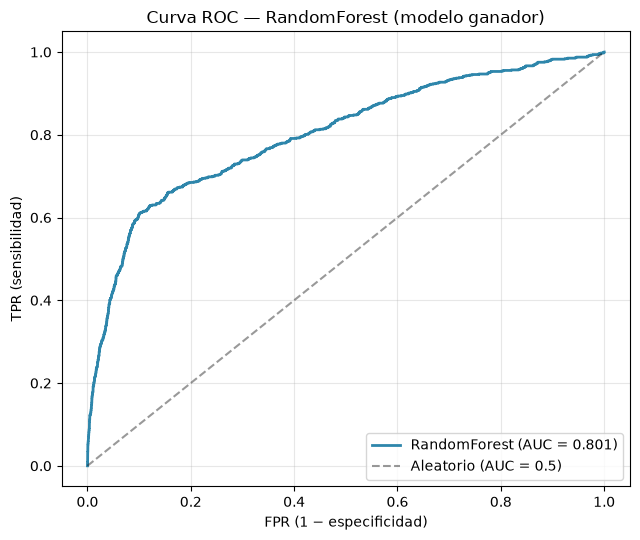

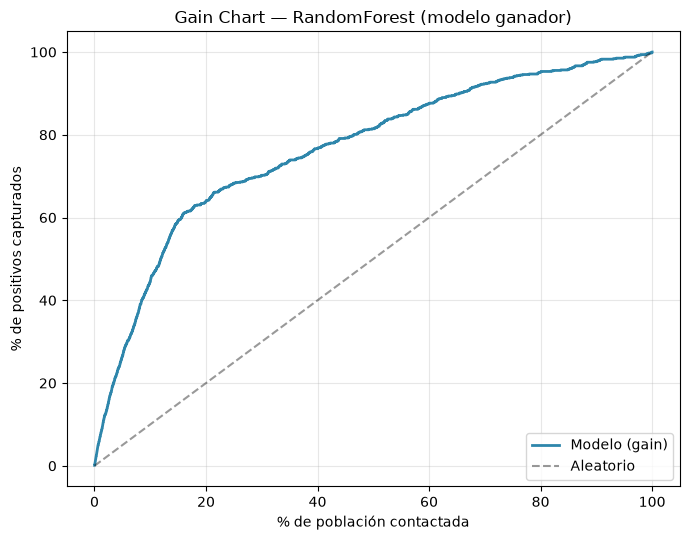

── Captura de positivos por decil de probabilidad ──
   Top  10% población  →  44.5% de positivos
   Top  20% población  →  63.9% de positivos
   Top  30% población  →  70.2% de positivos
   Top  40% población  →  76.6% de positivos
   Top  50% población  →  81.5% de positivos
   Top  60% población  →  87.5% de positivos
   Top  70% población  →  92.3% de positivos
   Top  80% población  →  95.2% de positivos
   Top  90% población  →  97.7% de positivos
   Top 100% población  →  100.0% de positivos


In [9]:
# ── FASE 2 · Curvas de evaluación (ROC y Gain/Lift) del ganador ────
# Evaluación honesta sobre el hold-out 25% (X_va / y_va de la Tarea 5)
from sklearn.metrics import roc_curve, roc_auc_score

# Carpeta de resultados de modelización
DIR_MODELIZACION = RESULTADOS / 'Modelizacion'
DIR_MODELIZACION.mkdir(parents=True, exist_ok=True)

# Probabilidades de la clase positiva sobre el hold-out
probas_va = modelo_perm.predict_proba(X_va)[:, 1]
auc_holdout = roc_auc_score(y_va, probas_va)
print(f'🎯 AUC en hold-out (25% reservado): {auc_holdout:.4f}')

# ── Curva ROC ────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_va, probas_va)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot(fpr, tpr, color='#2E86AB', lw=2,
        label=f'RandomForest (AUC = {auc_holdout:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Aleatorio (AUC = 0.5)')
ax.set_xlabel('FPR (1 − especificidad)')
ax.set_ylabel('TPR (sensibilidad)')
ax.set_title('Curva ROC — RandomForest (modelo ganador)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DIR_MODELIZACION / 'roc_curva.png', dpi=150)
plt.show()

# ── Gain / Lift chart ────────────────────────────────────────────────
df_eval = pd.DataFrame({'y_real': y_va.values, 'prob': probas_va})
df_eval = df_eval.sort_values('prob', ascending=False).reset_index(drop=True)

n_total = len(df_eval)
n_pos = int(df_eval['y_real'].sum())

df_eval['pct_poblacion'] = (np.arange(1, n_total + 1) / n_total) * 100.0
df_eval['pos_acum'] = df_eval['y_real'].cumsum()
df_eval['ganancia_acum'] = (100.0 * df_eval['pos_acum']) / n_pos

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(df_eval['pct_poblacion'], df_eval['ganancia_acum'],
        color='#2E86AB', lw=2, label='Modelo (gain)')
ax.plot([0, 100], [0, 100], 'k--', alpha=0.4, label='Aleatorio')
ax.set_xlabel('% de población contactada')
ax.set_ylabel('% de positivos capturados')
ax.set_title('Gain Chart — RandomForest (modelo ganador)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DIR_MODELIZACION / 'gain_chart.png', dpi=150)
plt.show()

# ── Resumen de captura de positivos por decil ───────────────────────
print('── Captura de positivos por decil de probabilidad ──')
for decil in range(1, 11):
    fila = df_eval.iloc[min(int(decil * n_total / 10.0) - 1, n_total - 1)]
    print(f'   Top {decil * 10:>3}% población  →  {fila["ganancia_acum"]:.1f}% de positivos')


## 🏁 FASE 3 — Finalización

### Tarea 6: Congelar configuración ganadora y persistir resultados

In [10]:
# ── FASE 3 · Tarea 6: Persistir configuración y resultados ────────
import json

# ── Top variables según Permutation Importance ──────────────────────
top_variables_perm = []
for i in range(min(8, len(df_perm))):
    fila = df_perm.iloc[i]
    top_variables_perm.append({
        'variable': fila['variable'],
        'importancia_perm': round(float(fila['importancia_perm']), 4),
    })

# ── Configuración del modelo ganador ────────────────────────────────
parametros_finales = dict(CONFIG_MODELOS[NOMBRE_GANADOR]['fijos'])
parametros_finales.update(resultados[NOMBRE_GANADOR]['best_params'])

config_final = {
    'tipo_proyecto': 'clasificacion_binaria',
    'objetivo_negocio': (
        'Scoring de probabilidad de contratación de fondos para '
        'priorizar campañas comerciales del banco.'
    ),
    'target': 'contrata_fondos',
    'dataset_entrenamiento': {
        'ruta': str(RUTA_DF),
        'n_filas': int(len(df)),
        'n_variables': int(X.shape[1]),
        'tasa_positivos_pct': round(100.0 * float(y.mean()), 2),
    },
    'algoritmo_ganador': {
        'nombre': 'RandomForestClassifier',
        'libreria': 'scikit-learn',
        'parametros': parametros_finales,
        'early_stopping': None,
        'nota': (
            'XGBoost no se probó (no instalado). El modelo final se '
            'entrenará con esta configuración sobre el dataset completo.'
        ),
    },
    'validacion': {
        'tipo': 'StratifiedKFold',
        'n_folds': N_FOLDS,
        'shuffle': True,
        'random_state': RANDOM_STATE,
        'metrica_principal': 'roc_auc',
    },
    'busqueda': {
        'metodo': 'RandomizedSearchCV',
        'n_iter_por_algoritmo': N_ITER,
        'scoring': SCORING,
    },
    'metricas_cv_modelo_ganador': {
        'auc_media': round(float(resultados[NOMBRE_GANADOR]['best_score']), 4),
        'auc_std': round(float(resultados[NOMBRE_GANADOR]['best_std']), 4),
    },
    'evaluacion_holdout_exploratoria': {
        'proporcion': 0.25,
        'auc': round(float(auc_holdout), 4),
        'nota': (
            'Evaluación exploratoria sobre 25% reservado. La evaluación '
            'definitiva sobre el dataset de validación externo se hará en '
            'una fase posterior con los pipelines completos.'
        ),
    },
    'interpretabilidad': {
        'fuente': 'Permutation Importance (scoring roc_auc) sobre hold-out 25%',
        'top_variables': top_variables_perm,
    },
}

ruta_config = DIR_MODELIZACION / 'config_mejor_modelo.json'
with open(ruta_config, 'w', encoding='utf-8') as f:
    json.dump(config_final, f, ensure_ascii=False, indent=2)

# ── Ranking completo (todas las combinaciones probadas) ─────────────
filas_completas = []
for nombre, r in resultados.items():
    cr = r['cv_results']
    for i in range(len(cr['params'])):
        filas_completas.append({
            'algoritmo': nombre,
            'params': str(cr['params'][i]),
            'auc_media': round(float(cr['mean_test_score'][i]), 4),
            'auc_std': round(float(cr['std_test_score'][i]), 4),
        })

df_completo = pd.DataFrame(filas_completas)
df_completo = df_completo.sort_values('auc_media', ascending=False).reset_index(drop=True)

df_ranking.to_csv(DIR_MODELIZACION / 'ranking_modelos.csv', index=False)
df_completo.to_csv(DIR_MODELIZACION / 'ranking_completo_modelos.csv', index=False)

# ── Importancias ─────────────────────────────────────────────────────
df_perm.to_csv(DIR_MODELIZACION / 'permutation_importance.csv', index=False)
df_imp_interna.to_csv(DIR_MODELIZACION / 'importancia_interna.csv', index=False)

print('✅ Artefactos guardados en:')
print(f'   - {ruta_config}')
print(f'   - {DIR_MODELIZACION / "ranking_modelos.csv"}')
print(f'   - {DIR_MODELIZACION / "ranking_completo_modelos.csv"}')
print(f'   - {DIR_MODELIZACION / "permutation_importance.csv"}')
print(f'   - {DIR_MODELIZACION / "importancia_interna.csv"}')
print(f'   - {DIR_MODELIZACION / "roc_curva.png"}')
print(f'   - {DIR_MODELIZACION / "gain_chart.png"}')


✅ Artefactos guardados en:
   - c:\Users\Admin\Desktop\Desktop\CarpetaFisica\Data Detective\Ciencia_Datos_2\Caso_Agentes\06_resultados\Modelizacion\config_mejor_modelo.json
   - c:\Users\Admin\Desktop\Desktop\CarpetaFisica\Data Detective\Ciencia_Datos_2\Caso_Agentes\06_resultados\Modelizacion\ranking_modelos.csv
   - c:\Users\Admin\Desktop\Desktop\CarpetaFisica\Data Detective\Ciencia_Datos_2\Caso_Agentes\06_resultados\Modelizacion\ranking_completo_modelos.csv
   - c:\Users\Admin\Desktop\Desktop\CarpetaFisica\Data Detective\Ciencia_Datos_2\Caso_Agentes\06_resultados\Modelizacion\permutation_importance.csv
   - c:\Users\Admin\Desktop\Desktop\CarpetaFisica\Data Detective\Ciencia_Datos_2\Caso_Agentes\06_resultados\Modelizacion\importancia_interna.csv
   - c:\Users\Admin\Desktop\Desktop\CarpetaFisica\Data Detective\Ciencia_Datos_2\Caso_Agentes\06_resultados\Modelizacion\roc_curva.png
   - c:\Users\Admin\Desktop\Desktop\CarpetaFisica\Data Detective\Ciencia_Datos_2\Caso_Agentes\06_resultados\